In [3]:
# import json

# notebook_path = '/content/Intrusion-Detection-in-Network-Traffic-/EDA.ipynb'

# with open(notebook_path, 'r') as f:
#     notebook_content = json.load(f)

# cells_to_generate = []
# previous_insert_id = '8-FoZP74BfkM'

# for cell in notebook_content['cells']:
#     cell_type = cell['cell_type']
#     source = ''.join(cell['source'])

#     if cell_type == 'code':
#         cells_to_generate.append({
#             'insert_after_cell_id': previous_insert_id,
#             'cell_type': 'python',
#             'code': source
#         })
#     elif cell_type == 'markdown':
#         cells_to_generate.append({
#             'insert_after_cell_id': previous_insert_id,
#             'cell_type': 'markdown',
#             'code': source
#         })

#     # Update previous_insert_id for the next cell (not directly applicable in this single-step response, but good practice)
#     # For this specific scenario, we are generating all at once, so '_AFTER_PREVIOUS_' will be used by the system.

# # This temporary cell is not actually generated as part of the plan.
# # The actual generated cells will be extracted from cells_to_generate and inserted below.

# Intrusion Detection in Network Traffic - Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis (EDA) on network traffic data for intrusion detection. The dataset contains various network features, and the goal is to understand the data distribution, identify patterns, and prepare it for building a machine learning model to detect network intrusions.

## Table of Contents

1.  [Load Data](#load_data)
2.  [Initial Data Inspection](#initial_inspection)
3.  [Missing Values](#missing_values)
4.  [Data Types](#data_types)
5.  [Descriptive Statistics](#descriptive_statistics)
6.  [Target Variable Analysis](#target_analysis)
7.  [Feature Distribution Analysis](#feature_distribution)
    *   [Categorical Features](#categorical_features)
    *   [Numerical Features](#numerical_features)
8.  [Correlation Analysis](#correlation_analysis)
9.  [Outlier Detection (Optional)](#outlier_detection)
10. [Conclusion and Next Steps](#conclusion)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

<a id="load_data"></a>
## 1. Load Data

We will load the training and testing datasets. The KDD Cup 1999 dataset is commonly used for network intrusion detection. It comes as `.txt` files, which we will load into pandas DataFrames.

In [5]:
# Define column names as per KDD Cup 1999 dataset description
colnames = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack_type", "last_flag"
]

# Load training data
train_df = pd.read_csv('/Users/laniyamohan/Desktop/PREDICTIVE/predict/Intrusion-Detection-in-Network-Traffic-/KDDTrain+.txt', names=colnames)

# Load testing data
test_df = pd.read_csv('/Users/laniyamohan/Desktop/PREDICTIVE/predict/Intrusion-Detection-in-Network-Traffic-/KDDTest+.txt', names=colnames)

In [6]:
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (125973, 43)
Testing data shape: (22544, 43)


In [7]:
display(train_df.head())
display(test_df.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,last_flag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,last_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


<a id="initial_inspection"></a>
## 2. Initial Data Inspection

We will perform basic checks on the data, such as `info()`, `describe()`, and `isnull().sum()` to get a quick overview of the dataset characteristics.

In [8]:
print("\n--- Training Data Info ---")
train_df.info()

print("\n--- Testing Data Info ---")
test_df.info()


--- Training Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-n

In [9]:
print("\n--- Training Data Description ---")
display(train_df.describe(include='all'))

print("\n--- Testing Data Description ---")
display(test_df.describe(include='all'))


--- Training Data Description ---


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,last_flag
count,125973.00000,125973,125973,125973,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973,125973.000000
unique,NaN,3,70,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,NaN
top,NaN,tcp,http,SF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,NaN
freq,NaN,102689,40338,74945,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67343,NaN
mean,287.14465,NaN,NaN,NaN,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,...,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,NaN,19.504060
std,2604.51531,NaN,NaN,NaN,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,...,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,NaN,2.291503
min,0.00000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,0.00000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,18.000000
50%,0.00000,NaN,NaN,NaN,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,20.000000
75%,0.00000,NaN,NaN,NaN,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,NaN,21.000000



--- Testing Data Description ---


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,last_flag
count,22544.000000,22544,22544,22544,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544,22544.000000
unique,NaN,3,64,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,NaN
top,NaN,tcp,http,SF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,NaN
freq,NaN,18880,7853,14875,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9711,NaN
mean,218.859076,NaN,NaN,NaN,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,...,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683,NaN,18.017965
std,1407.176612,NaN,NaN,NaN,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,...,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875,NaN,4.270361
min,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,17.000000
50%,0.000000,NaN,NaN,NaN,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,...,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,20.000000
75%,0.000000,NaN,NaN,NaN,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,NaN,21.000000


<a id="missing_values"></a>
## 3. Missing Values

Check for any missing values in both datasets.

In [10]:
print("\n--- Missing values in Training Data ---")
print(train_df.isnull().sum().sum())

print("\n--- Missing values in Testing Data ---")
print(test_df.isnull().sum().sum())


--- Missing values in Training Data ---
0

--- Missing values in Testing Data ---
0


Both datasets have no missing values, which is great!

<a id="data_types"></a>
## 4. Data Types

Inspect the data types of each column to ensure they are appropriate for analysis. We'll also identify categorical and numerical features.

In [11]:
print("\n--- Training Data Types ---")
print(train_df.dtypes)

print("\n--- Testing Data Types ---")
print(test_df.dtypes)


--- Training Data Types ---
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    floa

In [12]:
# Identify categorical and numerical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns
numerical_cols = train_df.select_dtypes(include=np.number).columns

print("\nCategorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())


Categorical Columns: ['protocol_type', 'service', 'flag', 'attack_type']
Numerical Columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'last_flag']


<a id="descriptive_statistics"></a>
## 5. Descriptive Statistics

Examine the descriptive statistics for numerical features to understand their central tendency, dispersion, and shape. For categorical features, we'll look at value counts.

In [13]:
print("\n--- Descriptive statistics for numerical features (Training Data) ---")
display(train_df[numerical_cols].describe())

print("\n--- Descriptive statistics for numerical features (Testing Data) ---")
display(test_df[numerical_cols].describe())


--- Descriptive statistics for numerical features (Training Data) ---


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000



--- Descriptive statistics for numerical features (Testing Data) ---


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683,18.017965
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875,4.270361
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,21.000000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [14]:
print("\n--- Value counts for categorical features (Training Data) ---")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(train_df[col].value_counts())

print("\n--- Value counts for categorical features (Testing Data) ---")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(test_df[col].value_counts())


--- Value counts for categorical features (Training Data) ---

Column: protocol_type
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64

Column: flag
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64

Column: attack_type
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buf

Observations from descriptive statistics:
*   Many numerical features have a wide range, indicating potential need for scaling.
*   Features like `duration`, `src_bytes`, `dst_bytes` have extremely large maximum values and often a high number of zeros, suggesting skewed distributions and presence of outliers.
*   Categorical features `protocol_type`, `service`, and `flag` have varying numbers of unique values. `attack_type` is the target variable.

<a id="target_analysis"></a>
## 6. Target Variable Analysis

`attack_type` is our target variable. We need to understand its distribution and whether the dataset is imbalanced. We also need to map the various attack types into broader categories (e.g., 'normal', 'dos', 'probe', 'r2l', 'u2r').

In [15]:
print("\n--- Attack Type Distribution (Training Data) ---")
print(train_df['attack_type'].value_counts())

print("\n--- Attack Type Distribution (Testing Data) ---")
print(test_df['attack_type'].value_counts())


--- Attack Type Distribution (Training Data) ---
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

--- Attack Type Distribution (Testing Data) ---
attack_type
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint       

In [16]:
# Define a function to map attack types to broader categories
def map_attack_type(attack):
    attack = attack.strip() # Remove any leading/trailing whitespace
    dos_attacks = ['apache2', 'back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'mailbomb', 'processtable', 'udpstorm', 'worm']
    probe_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
    r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 'xlock', 'xsnoop', 'snmpgetattack', 'httptunnel', 'sendmail', 'named']
    u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'xterm', 'ps', 'sqlattack', 'printer']

    if attack == 'normal':
        return 'normal'
    elif attack in dos_attacks:
        return 'dos'
    elif attack in probe_attacks:
        return 'probe'
    elif attack in r2l_attacks:
        return 'r2l'
    elif attack in u2r_attacks:
        return 'u2r'
    else:
        return 'other' # Should not happen with this dataset but good for robustness

# Apply the mapping to both training and testing datasets
train_df['attack_category'] = train_df['attack_type'].apply(map_attack_type)
test_df['attack_category'] = test_df['attack_type'].apply(map_attack_type)

print("\n--- Attack Category Distribution (Training Data) ---")
print(train_df['attack_category'].value_counts())

print("\n--- Attack Category Distribution (Testing Data) ---")
print(test_df['attack_category'].value_counts())


--- Attack Category Distribution (Training Data) ---
attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

--- Attack Category Distribution (Testing Data) ---
attack_category
normal    9711
dos       7460
r2l       2554
probe     2421
other      331
u2r         67
Name: count, dtype: int64


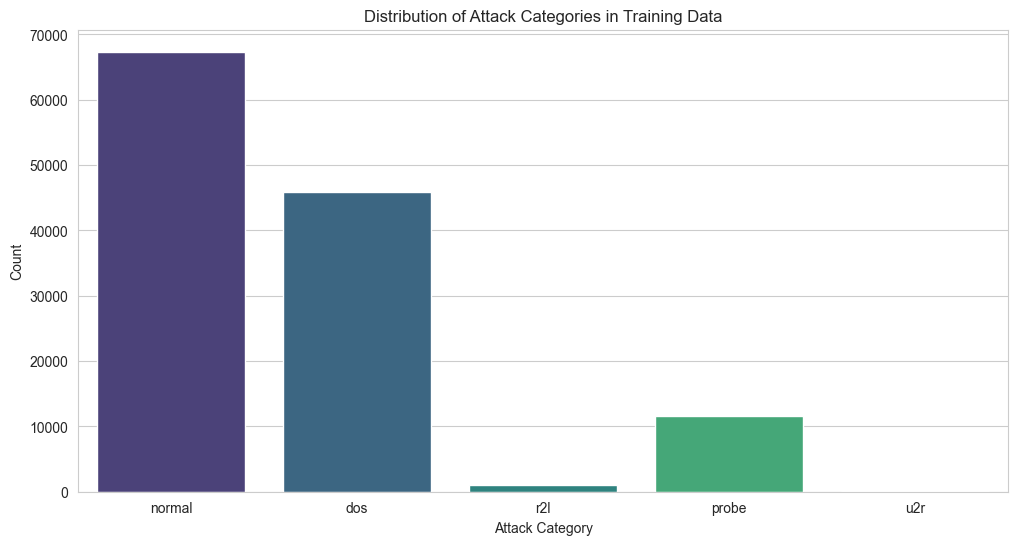

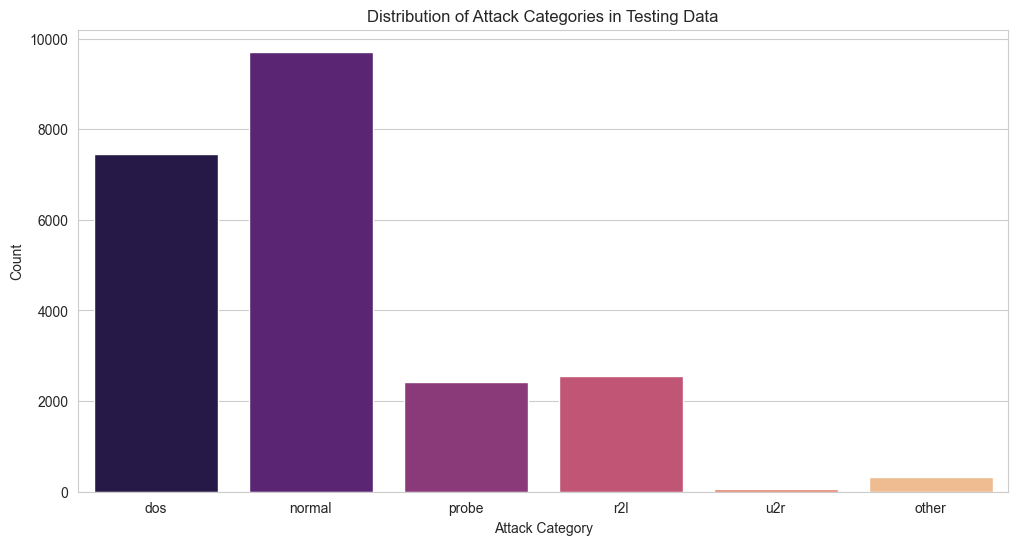

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='attack_category', palette='viridis')
plt.title('Distribution of Attack Categories in Training Data')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=test_df, x='attack_category', palette='magma')
plt.title('Distribution of Attack Categories in Testing Data')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.show()

The distribution of attack categories shows significant imbalance, with 'normal' and 'dos' attacks being the most prevalent. This imbalance needs to be addressed during model training to prevent bias towards majority classes.

<a id="feature_distribution"></a>
## 7. Feature Distribution Analysis

We will analyze the distribution of both categorical and numerical features to gain deeper insights into their characteristics and relationships with the target variable.

<a id="categorical_features"></a>
### Categorical Features

Visualize the distribution of categorical features and their relationship with the attack categories.

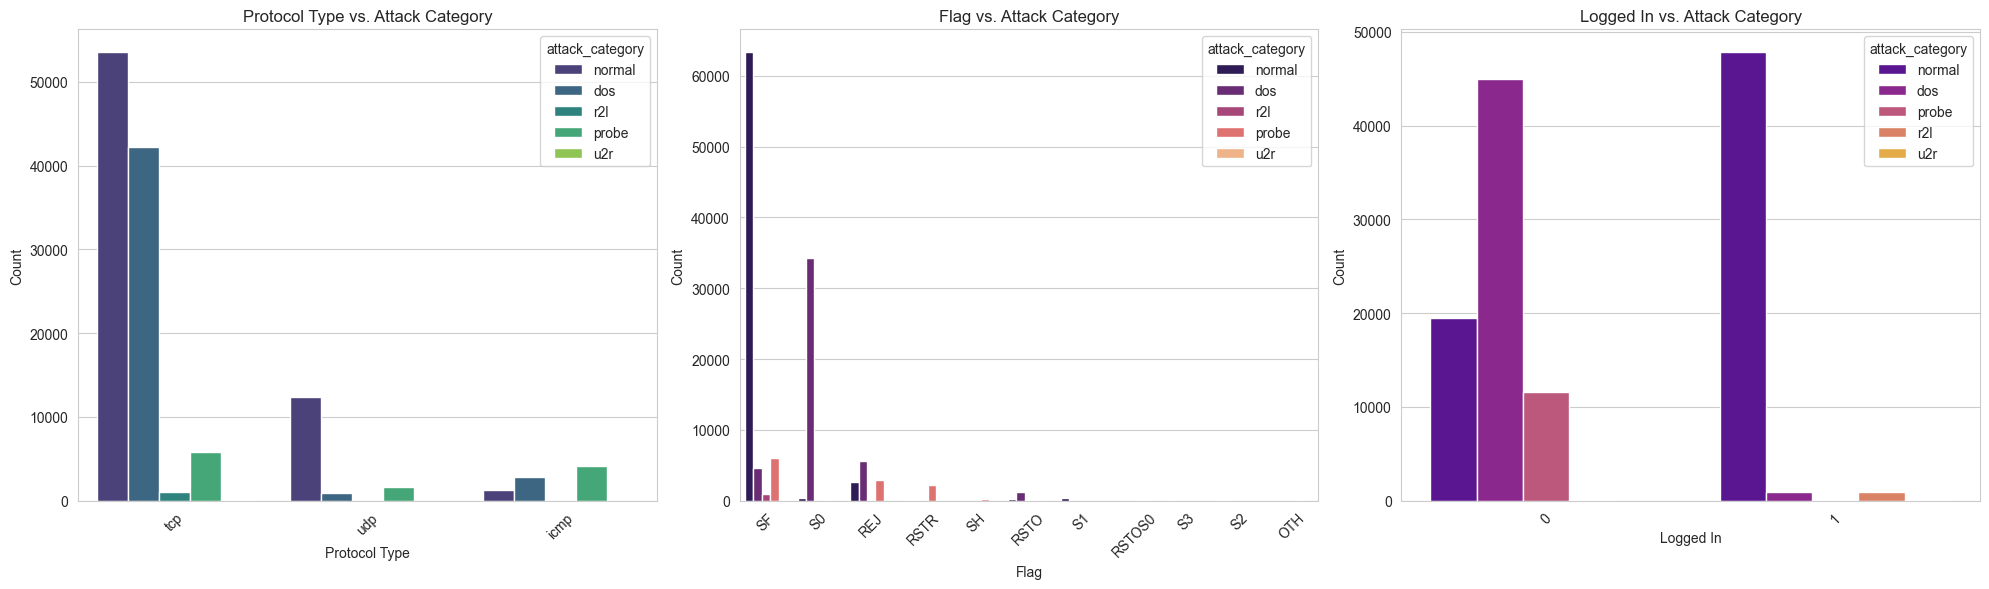

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=train_df, x='protocol_type', hue='attack_category', palette='viridis', ax=axes[0])
axes[0].set_title('Protocol Type vs. Attack Category')
axes[0].set_xlabel('Protocol Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=train_df, x='flag', hue='attack_category', palette='magma', ax=axes[1])
axes[1].set_title('Flag vs. Attack Category')
axes[1].set_xlabel('Flag')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=train_df, x='logged_in', hue='attack_category', palette='plasma', ax=axes[2])
axes[2].set_title('Logged In vs. Attack Category')
axes[2].set_xlabel('Logged In')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Observations:
*   **Protocol Type:** `tcp` is dominant, and most attacks (especially `dos`) occur over `tcp`. `icmp` is associated with `probe` attacks. `udp` also has some `dos` attacks.
*   **Flag:** Certain flags are highly indicative of specific attack types. For example, `SF` is common for normal traffic, but also for `dos` and `probe`.
*   **Logged In:** `logged_in=1` (user is logged in) is mostly associated with normal traffic, as expected. `r2l` and `u2r` attacks might be related to login attempts.

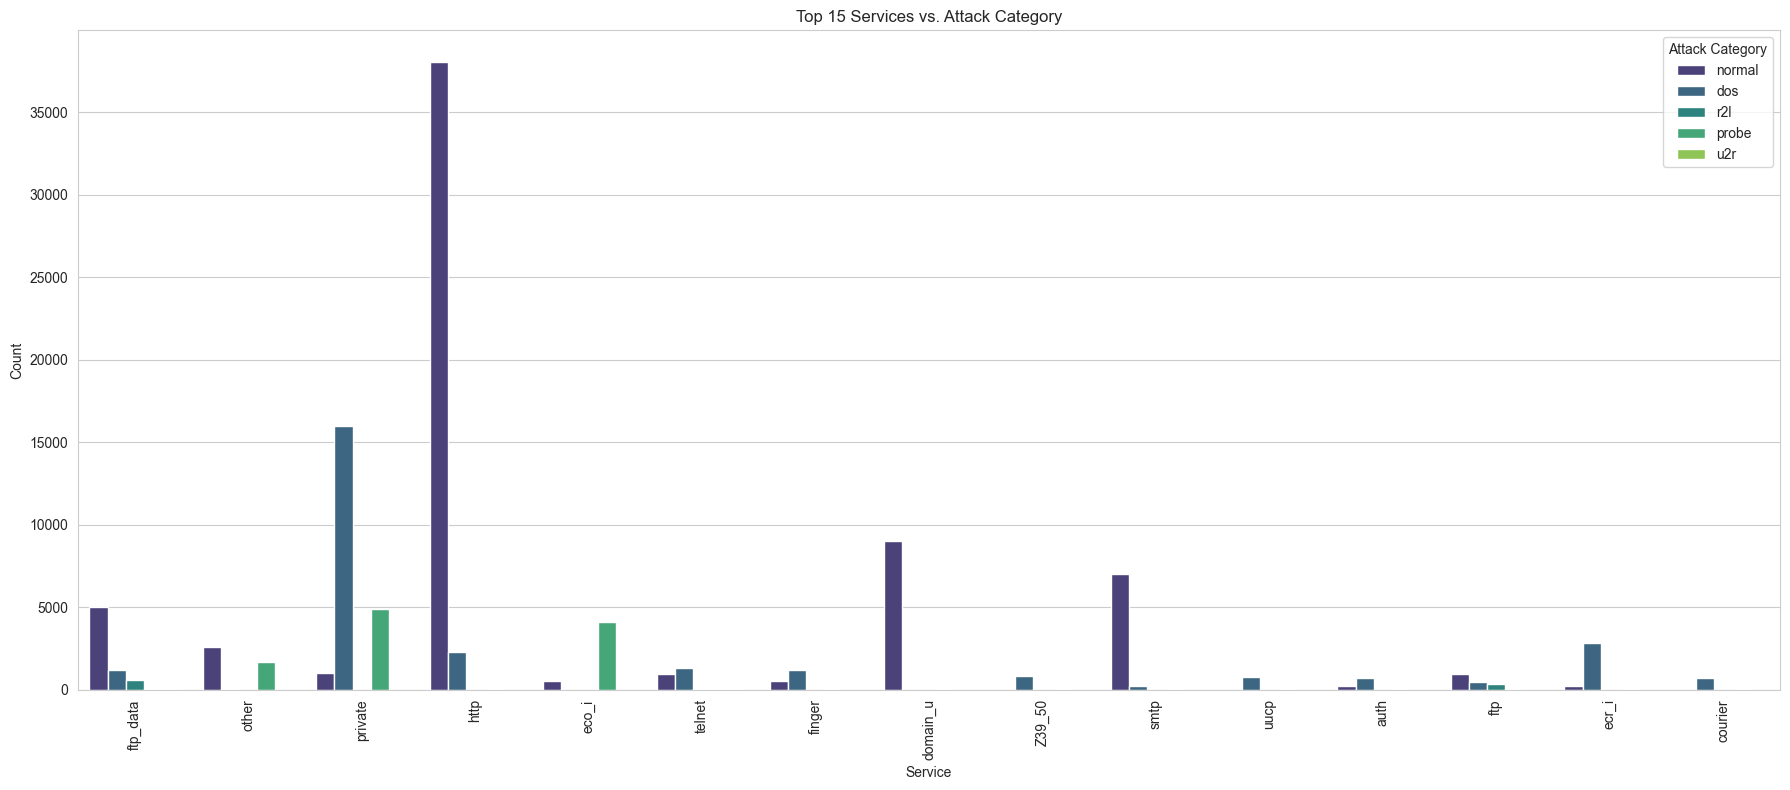

In [19]:
# For 'service' feature, due to many unique values, let's visualize top N services
plt.figure(figsize=(18, 8))
top_services = train_df['service'].value_counts().nlargest(15).index # Top 15 services
sns.countplot(data=train_df[train_df['service'].isin(top_services)], x='service', hue='attack_category', palette='viridis')
plt.title('Top 15 Services vs. Attack Category')
plt.xlabel('Service')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Attack Category')
plt.tight_layout()
plt.show()

Observations on **Service**:
*   `http` is the most common service, mostly associated with normal traffic. However, it also sees a significant number of `dos` attacks.
*   `private` and `ecr_i` services are heavily associated with `dos` attacks.
*   `ftp_data` shows some `r2l` attacks.
*   The service feature is highly discriminative.

<a id="numerical_features"></a>
### Numerical Features

Visualize the distribution of key numerical features using histograms and box plots, and their relationship with the target variable.

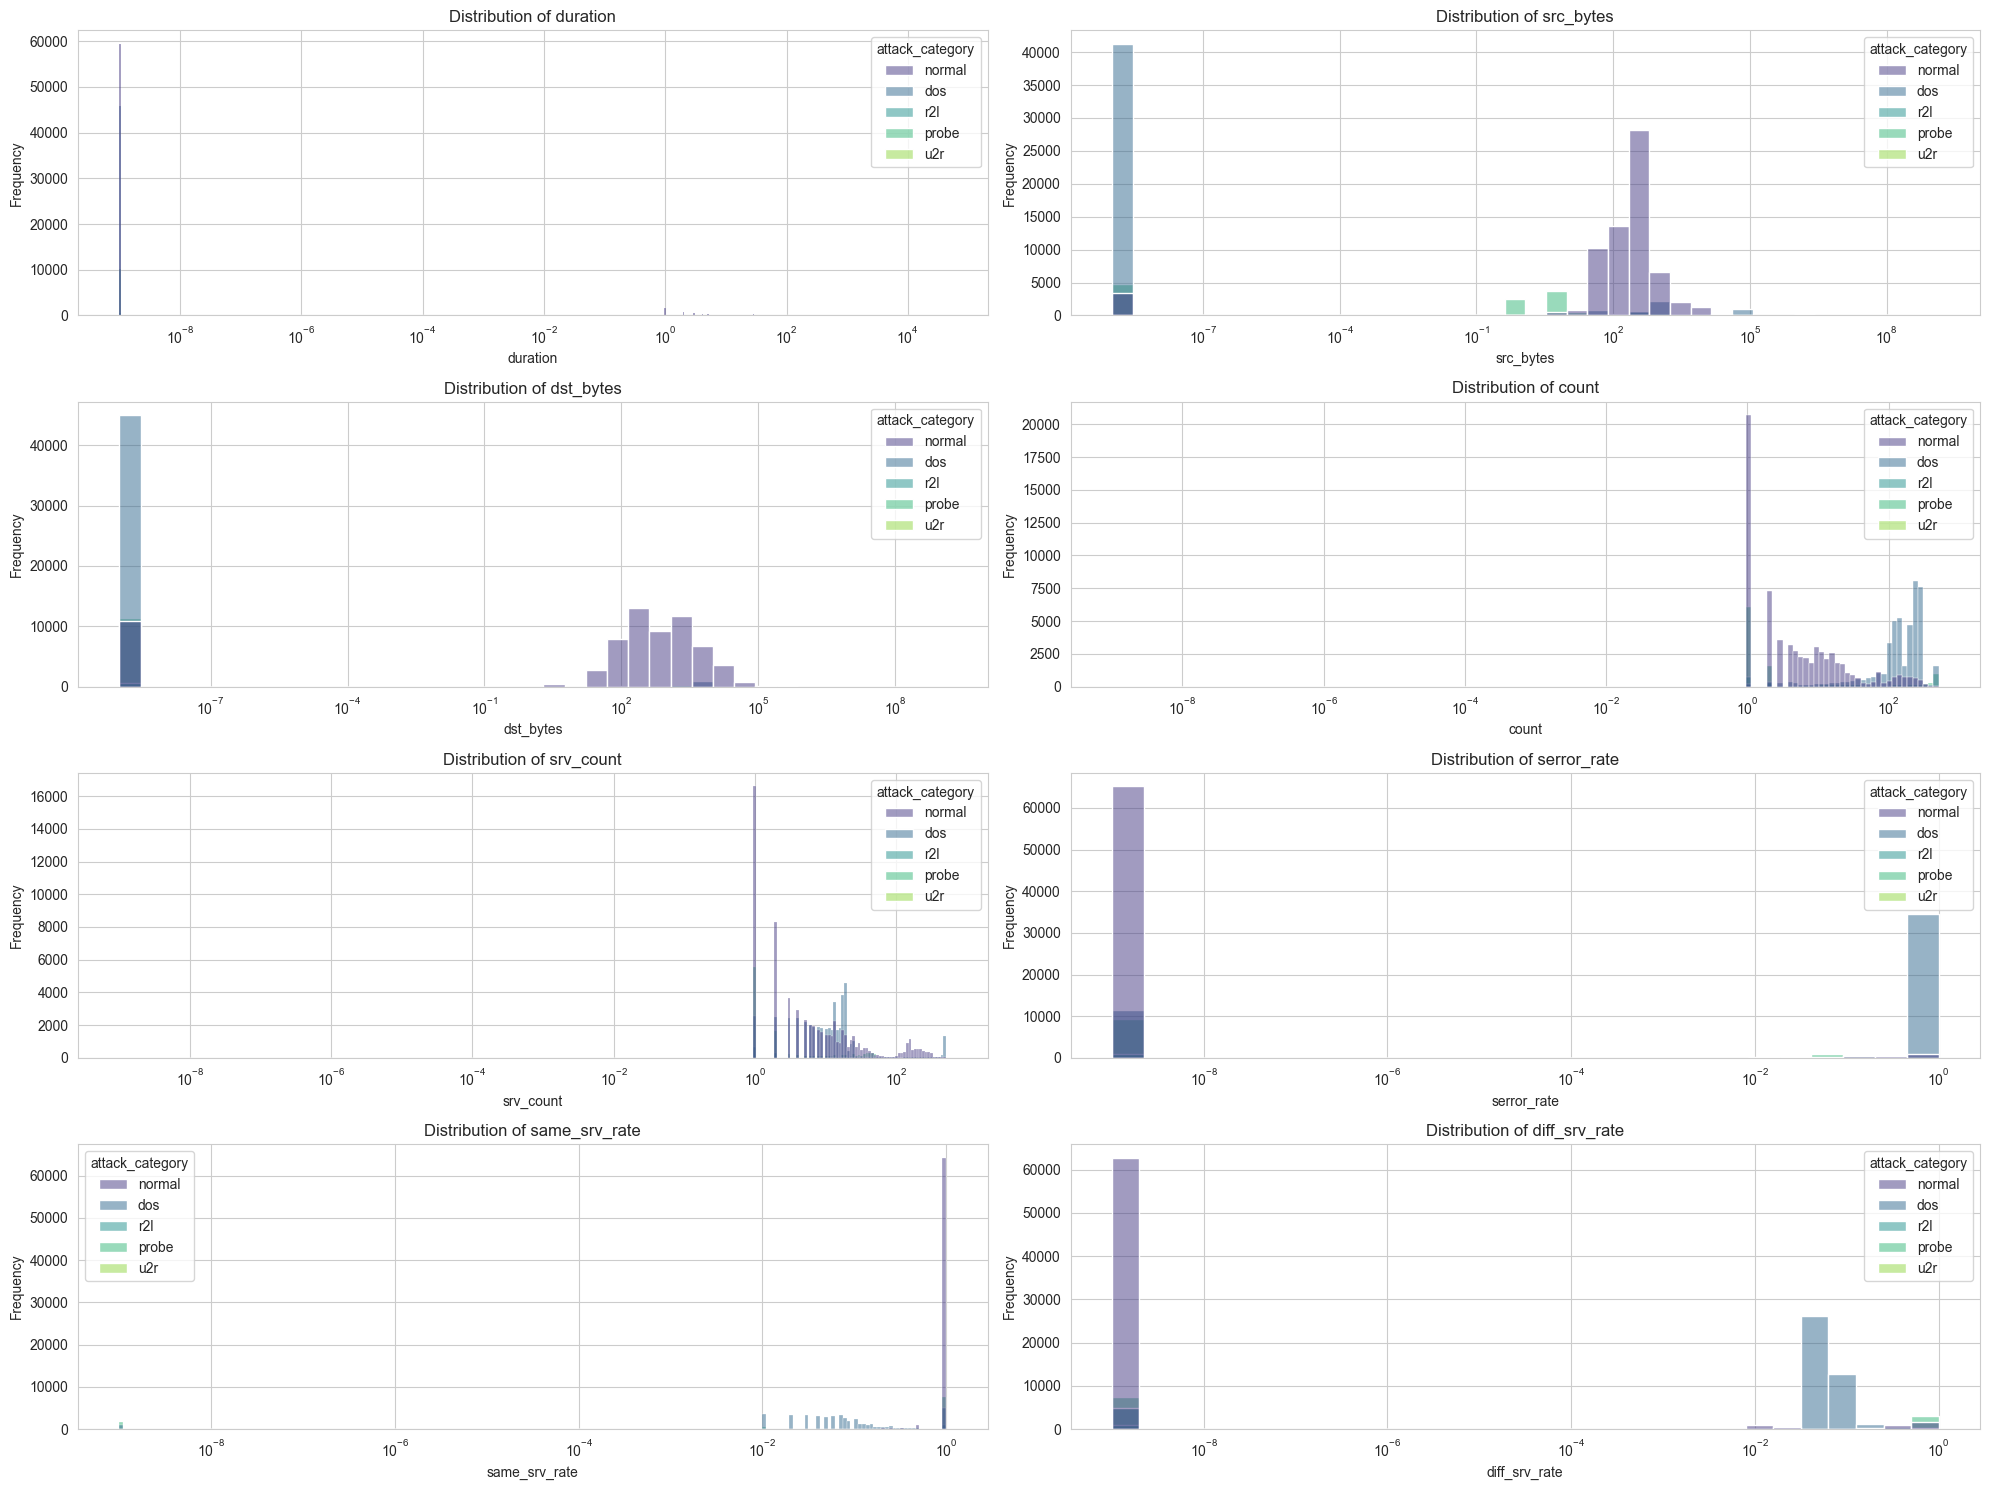

In [20]:
selected_numerical_cols = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'same_srv_rate', 'diff_srv_rate']

plt.figure(figsize=(20, 15))

# Create a temporary DataFrame to modify for plotting, replacing zeros with a small epsilon
train_df_temp = train_df.copy() # Copy the whole DataFrame to preserve original indices and 'attack_category'
epsilon = 1e-9 # A very small positive number

for col in selected_numerical_cols:
    # Replace zero values with epsilon in the temporary DataFrame for selected numerical columns
    train_df_temp[col] = train_df_temp[col].replace(0, epsilon)

    plt.subplot(4, 2, selected_numerical_cols.index(col) + 1)
    # Use train_df_temp for plotting, which has the modified column data
    # Removed 'kde=True' to resolve ValueError with log-scaled data
    sns.histplot(data=train_df_temp, x=col, hue='attack_category', palette='viridis', log_scale=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

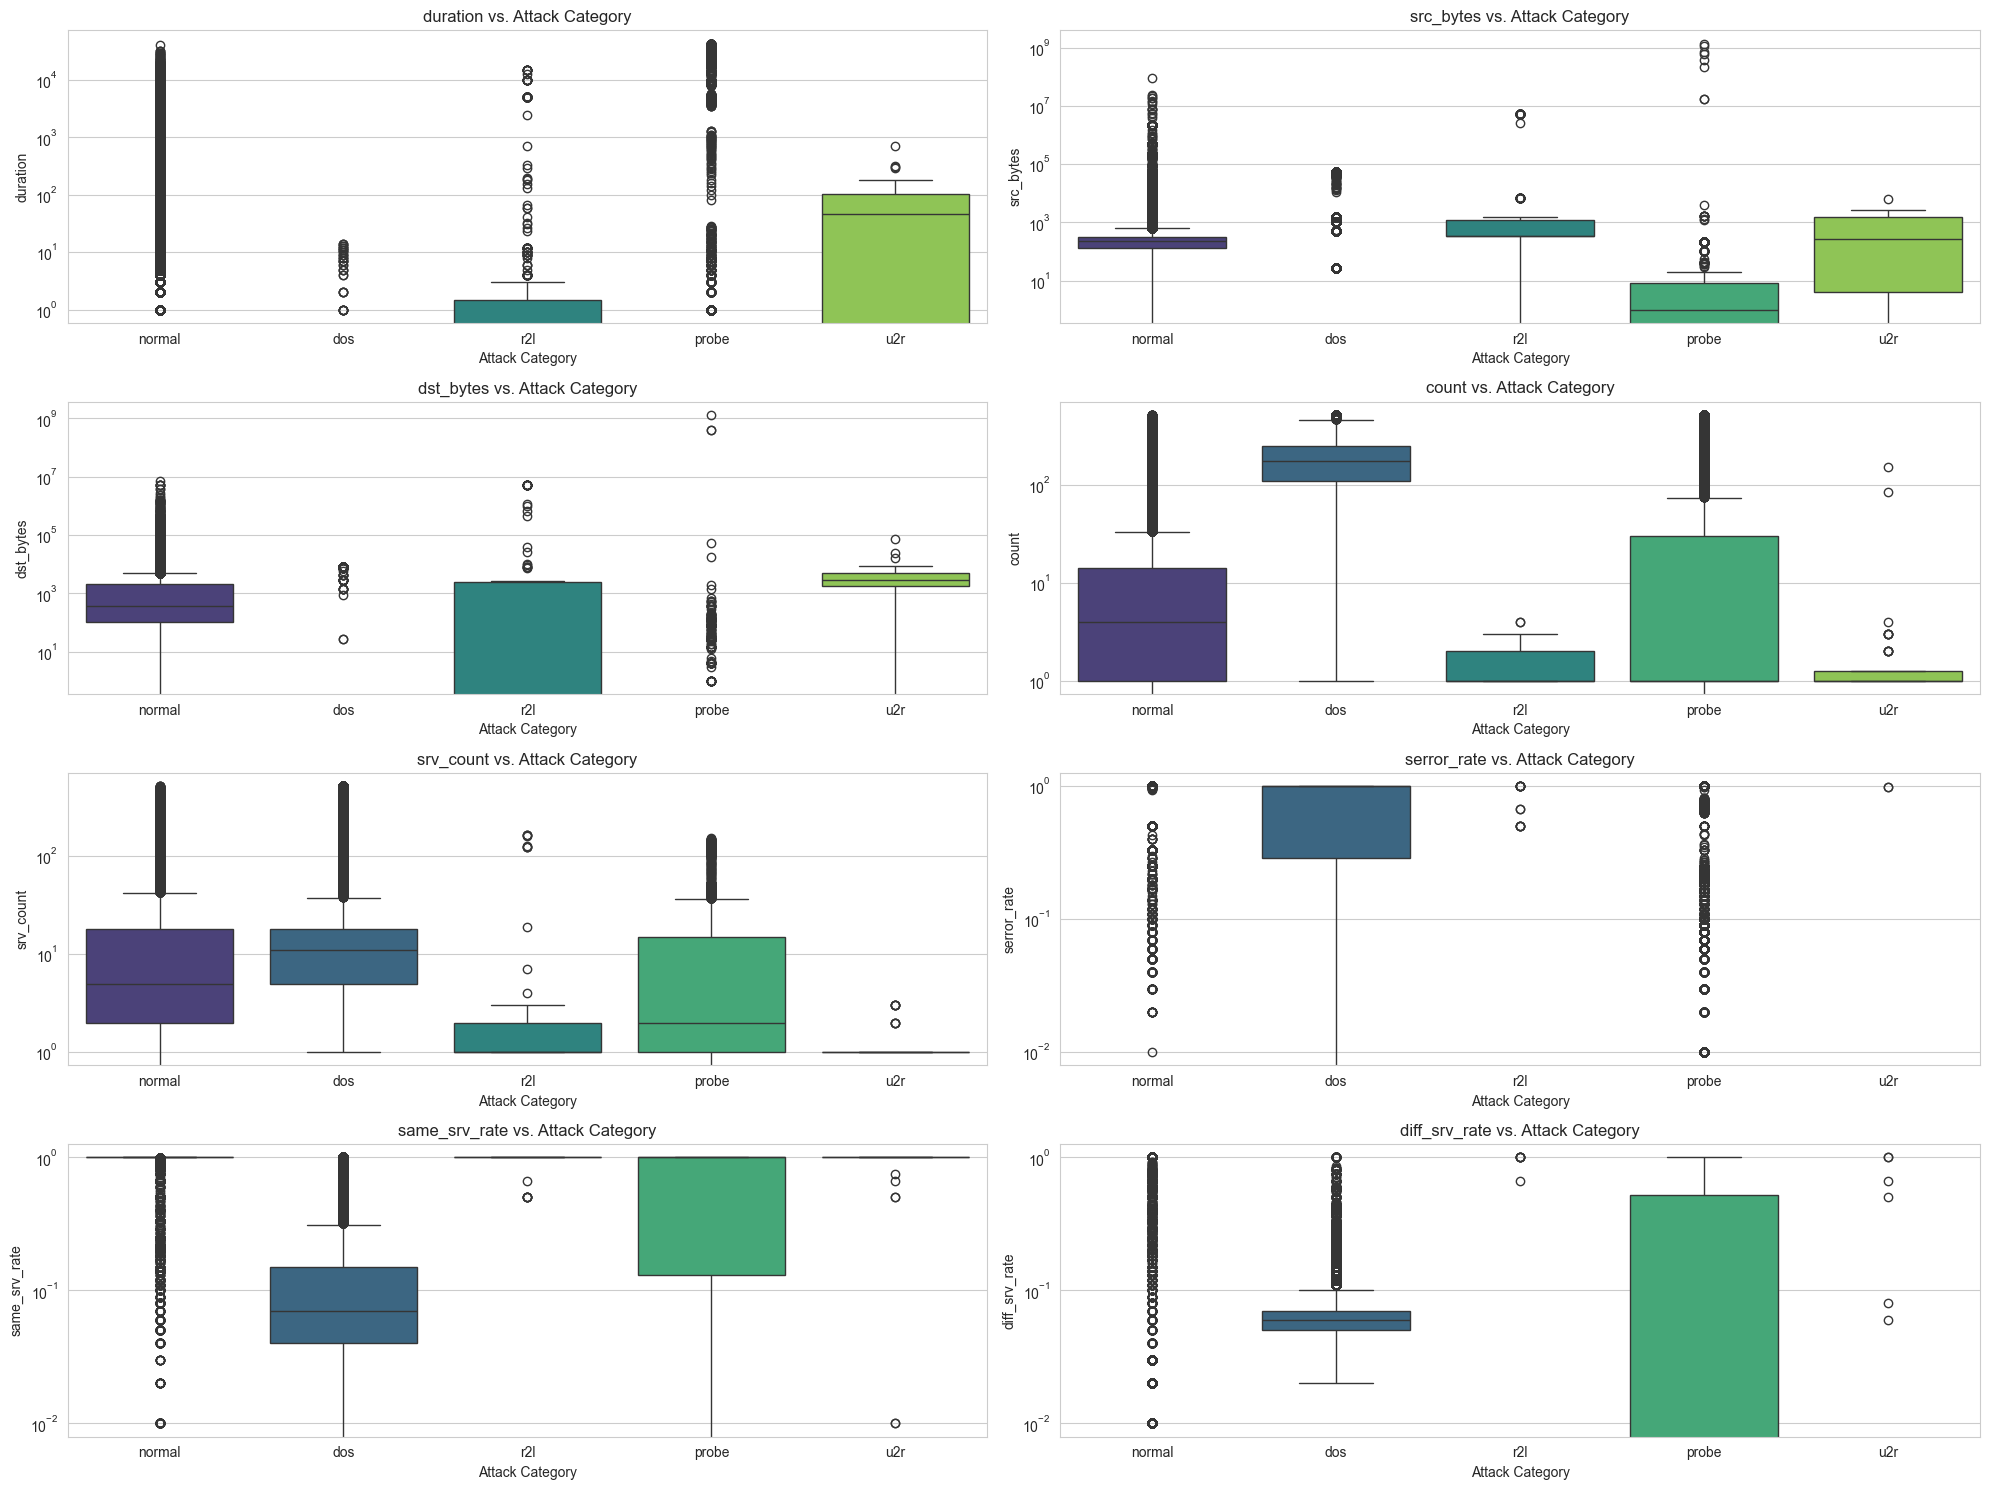

In [21]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(data=train_df, x='attack_category', y=col, palette='viridis')
    plt.title(f'{col} vs. Attack Category')
    plt.xlabel('Attack Category')
    plt.ylabel(col)
    plt.yscale('log') # Use log scale for y-axis due to large range
plt.tight_layout()
plt.show()

Observations from numerical features:
*   **Duration:** Most connections have a duration of 0. Longer durations might be associated with normal or specific attack types (`r2l`, `u2r`).
*   **Src Bytes / Dst Bytes:** Highly skewed, with many zero values. These distinguish between different attack types and normal traffic.
*   **Count / Srv Count:** These features often show differences between normal and `dos` attacks (e.g., high counts for `dos`).
*   **Serror Rate:** High `serror_rate` indicates connection errors, common in `dos` attacks.
*   **Same Srv Rate / Diff Srv Rate:** These ratios are very important for detecting `dos` and `probe` attacks. High `same_srv_rate` often accompanies `dos` attacks.

<a id="correlation_analysis"></a>
## 8. Correlation Analysis

Examine the correlation matrix of numerical features to identify highly correlated features. High correlation can indicate multicollinearity, which might be addressed in feature selection or dimensionality reduction.

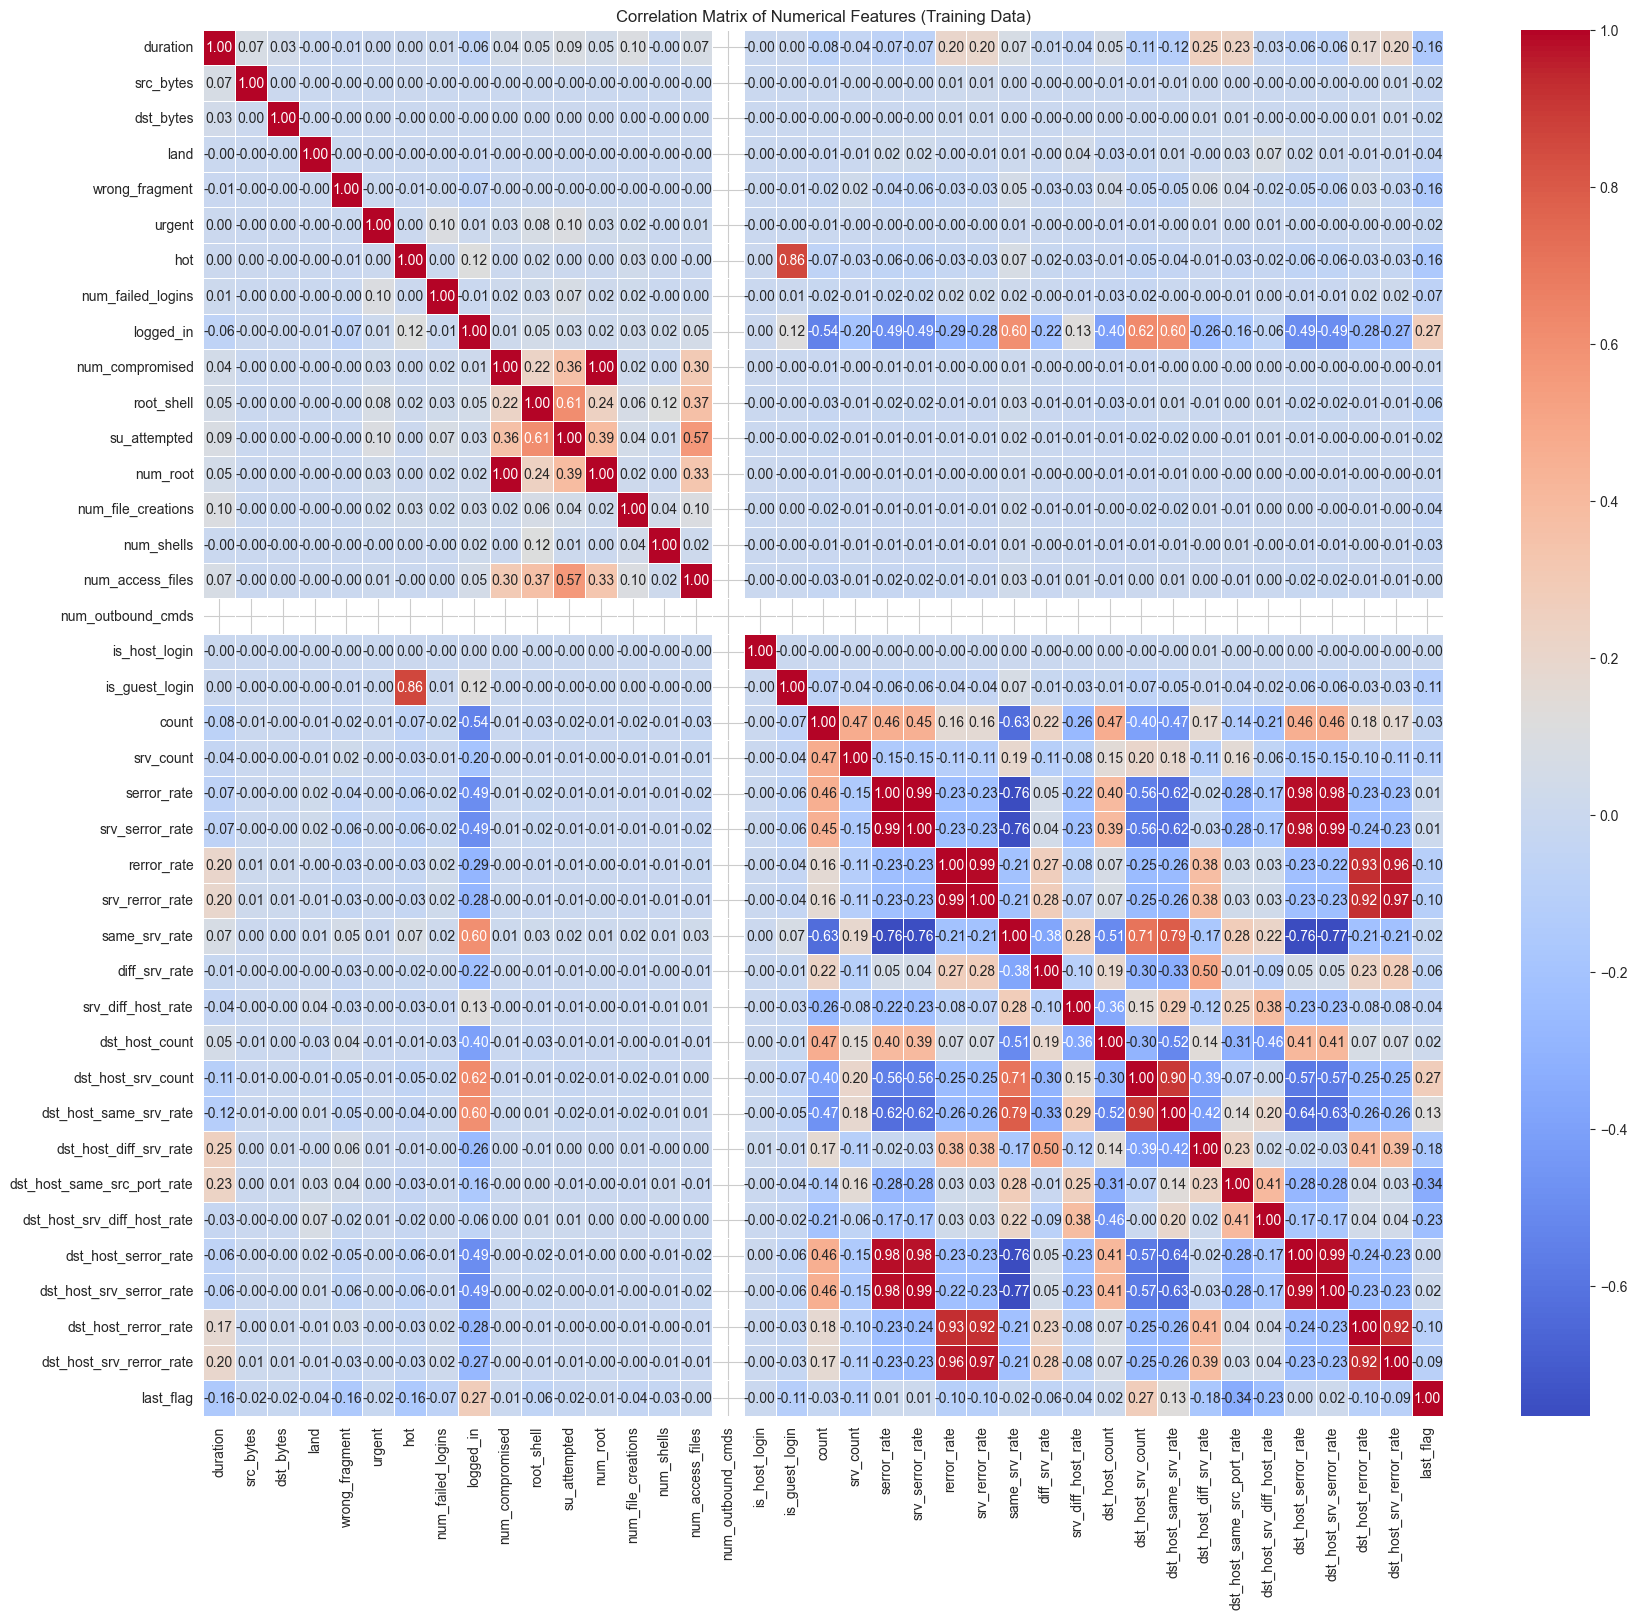

In [22]:
plt.figure(figsize=(20, 18))
sns.heatmap(train_df[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Training Data)')
plt.show()

Observations from correlation matrix:
*   Many features are highly correlated, e.g., `serror_rate` and `srv_serror_rate`, `rerror_rate` and `srv_rerror_rate`, `dst_host_serror_rate` and `dst_host_srv_serror_rate`.
*   Features like `count`, `srv_count`, `same_srv_rate`, `diff_srv_rate`, and various `dst_host` related features show significant correlations, which is expected as they are derived from similar network statistics.
*   This suggests that some features might be redundant, and feature selection or PCA could be beneficial.

<a id="outlier_detection"></a>
## 9. Outlier Detection (Optional)

Given the highly skewed distributions of many numerical features, it's evident that outliers exist. While some models are robust to outliers, others might require outlier treatment. For now, we will just acknowledge their presence through box plots and descriptive statistics.

<a id="conclusion"></a>
## 10. Conclusion and Next Steps

Through this EDA, we have gained several key insights:

*   **Data Quality:** No missing values were found.
*   **Data Types:** Categorical and numerical features were identified.
*   **Target Imbalance:** The `attack_category` is highly imbalanced, requiring careful handling (e.g., oversampling, undersampling, or using appropriate evaluation metrics).
*   **Feature Distributions:** Many numerical features are highly skewed with significant outliers.
*   **Categorical Features:** `protocol_type`, `service`, `flag`, and `logged_in` show strong discriminative power for attack categories.
*   **Numerical Features:** `duration`, `src_bytes`, `dst_bytes`, connection rates (`count`, `srv_count`, `same_srv_rate`), and error rates (`serror_rate`, `rerror_rate`) are crucial for distinguishing between normal and various attack types.
*   **Correlation:** High correlation exists among several numerical features.

**Next Steps:**

1.  **Preprocessing:**
    *   **Categorical Encoding:** Convert categorical features into numerical representations (e.g., One-Hot Encoding or Label Encoding).
    *   **Feature Scaling:** Scale numerical features (e.g., StandardScaler, MinMaxScaler) to handle different ranges and skewed distributions.
    *   **Outlier Treatment:** Depending on the chosen model, decide on a strategy for outliers (e.g., clipping, transformation, or using robust models).
2.  **Feature Engineering:** Create new features from existing ones if applicable (e.g., interaction terms).
3.  **Feature Selection/Dimensionality Reduction:** Address multicollinearity and reduce dimensionality if needed.
4.  **Model Building:** Train various classification models for intrusion detection.
5.  **Model Evaluation:** Evaluate models using appropriate metrics (e.g., precision, recall, F1-score, confusion matrix) especially considering the imbalanced dataset.

This EDA provides a solid foundation for proceeding with the machine learning task of network intrusion detection.

## 11. Data Preprocessing

Before training any machine learning models, we need to preprocess the data. This includes encoding categorical features, scaling numerical features, and preparing the target variable.

In [23]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Make copies to avoid modifying original DFs
train_df_processed = train_df.copy()
test_df_processed = test_df.copy()

# --- 11.1 Target Variable Encoding ---

# Define all possible attack categories explicitly from the map_attack_type function
# This ensures the LabelEncoder is aware of all categories, even if some don't appear in training data.
all_possible_attack_categories = ['normal', 'dos', 'probe', 'r2l', 'u2r', 'other']

le = LabelEncoder()
le.fit(all_possible_attack_categories) # Fit on all potential categories

train_df_processed['attack_category_encoded'] = le.transform(train_df_processed['attack_category'])
test_df_processed['attack_category_encoded'] = le.transform(test_df_processed['attack_category'])

print("Encoded attack categories (Training Data):\n", train_df_processed['attack_category_encoded'].value_counts())
print("\nEncoded attack categories (Testing Data):\n", test_df_processed['attack_category_encoded'].value_counts())
print("\nOriginal labels and their encoded values:", dict(zip(le.classes_, le.transform(le.classes_))))

# Drop the original 'attack_type' and 'attack_category' columns
train_df_processed = train_df_processed.drop(columns=['attack_type', 'attack_category', 'last_flag'])
test_df_processed = test_df_processed.drop(columns=['attack_type', 'attack_category', 'last_flag'])

# Update categorical and numerical columns lists after dropping target and 'last_flag'
# 'last_flag' is often dropped as it's a legacy KDD feature not directly related to traffic attributes.
categorical_cols = categorical_cols.drop(['attack_type'])
numerical_cols = numerical_cols.drop(['last_flag'])

display(train_df_processed.head())

Encoded attack categories (Training Data):
 attack_category_encoded
1    67343
0    45927
3    11656
4      995
5       52
Name: count, dtype: int64

Encoded attack categories (Testing Data):
 attack_category_encoded
1    9711
0    7460
4    2554
3    2421
2     331
5      67
Name: count, dtype: int64

Original labels and their encoded values: {np.str_('dos'): np.int64(0), np.str_('normal'): np.int64(1), np.str_('other'): np.int64(2), np.str_('probe'): np.int64(3), np.str_('r2l'): np.int64(4), np.str_('u2r'): np.int64(5)}


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_category_encoded
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


### 11.2 Categorical Feature Encoding

We will use One-Hot Encoding for the `protocol_type`, `service`, and `flag` features. This converts categorical variables into a format that can be provided to ML algorithms to do a better job.

In [24]:
train_df_encoded = pd.get_dummies(train_df_processed, columns=categorical_cols, drop_first=False)
test_df_encoded = pd.get_dummies(test_df_processed, columns=categorical_cols, drop_first=False)

# Align columns - crucial for consistent feature sets between train and test
# This handles cases where test data might have categories not present in train, or vice versa
train_labels = train_df_encoded['attack_category_encoded']
test_labels = test_df_encoded['attack_category_encoded']

# Drop labels before aligning features
train_features = train_df_encoded.drop(columns=['attack_category_encoded'])
test_features = test_df_encoded.drop(columns=['attack_category_encoded'])

train_features, test_features = train_features.align(test_features, join='outer', axis=1, fill_value=0)

# Re-add labels
train_features['attack_category_encoded'] = train_labels
test_features['attack_category_encoded'] = test_labels

print("Shape of training data after one-hot encoding:", train_features.shape)
print("Shape of testing data after one-hot encoding:", test_features.shape)
display(train_features.head())

Shape of training data after one-hot encoding: (125973, 123)
Shape of testing data after one-hot encoding: (22544, 123)


,count,diff_srv_rate,dst_bytes,dst_host_count,dst_host_diff_srv_rate,dst_host_rerror_rate,dst_host_same_src_port_rate,dst_host_same_srv_rate,dst_host_serror_rate,dst_host_srv_count,...,service_whois,src_bytes,srv_count,srv_diff_host_rate,srv_rerror_rate,srv_serror_rate,su_attempted,urgent,wrong_fragment,attack_category_encoded
0,2,0.00,0,150,0.03,0.05,0.17,0.17,0.00,25,...,False,491,2,0.00,0.0,0.0,0,0,0,1
1,13,0.15,0,255,0.60,0.00,0.88,0.00,0.00,1,...,False,146,1,0.00,0.0,0.0,0,0,0,1
2,123,0.07,0,255,0.05,0.00,0.00,0.10,1.00,26,...,False,0,6,0.00,0.0,1.0,0,0,0,0
3,5,0.00,8153,30,0.00,0.00,0.03,1.00,0.03,255,...,False,232,5,0.00,0.0,0.2,0,0,0,1
4,30,0.00,420,255,0.00,0.00,0.00,1.00,0.00,255,...,False,199,32,0.09,0.0,0.0,0,0,0,1


### 11.3 Numerical Feature Scaling

We will use `StandardScaler` to scale numerical features. This will standardize features by removing the mean and scaling to unit variance. This is important for many machine learning algorithms that are sensitive to the scale of input features (e.g., SVMs, neural networks, and algorithms that use distance metrics).

In [25]:
from sklearn.preprocessing import StandardScaler

# Extract numerical columns from the feature set (excluding the encoded target)
numerical_cols_after_encoding = [col for col in numerical_cols if col in train_features.columns]

scaler = StandardScaler()

# Apply scaling to training features
train_features[numerical_cols_after_encoding] = scaler.fit_transform(train_features[numerical_cols_after_encoding])

# Apply scaling to testing features (use scaler fitted on training data)
test_features[numerical_cols_after_encoding] = scaler.transform(test_features[numerical_cols_after_encoding])

display(train_features.head())

,count,diff_srv_rate,dst_bytes,dst_host_count,dst_host_diff_srv_rate,dst_host_rerror_rate,dst_host_same_src_port_rate,dst_host_same_srv_rate,dst_host_serror_rate,dst_host_srv_count,...,service_whois,src_bytes,srv_count,srv_diff_host_rate,srv_rerror_rate,srv_serror_rate,su_attempted,urgent,wrong_fragment,attack_category_encoded
0,-0.717045,-0.349683,-0.004919,-0.324063,-0.280282,-0.224532,0.069972,-0.782367,-0.639532,-0.818890,...,False,-0.007679,-0.354343,-0.374560,-0.374432,-0.631929,-0.024437,-0.007736,-0.089486,1
1,-0.620982,0.482201,-0.004919,0.734343,2.736852,-0.387635,2.367737,-1.161030,-0.639532,-1.035688,...,False,-0.007737,-0.368110,-0.374560,-0.374432,-0.631929,-0.024437,-0.007736,-0.089486,1
2,0.339648,0.038529,-0.004919,0.734343,-0.174417,-0.387635,-0.480197,-0.938287,1.608759,-0.809857,...,False,-0.007762,-0.299273,-0.374560,-0.374432,1.605104,-0.024437,-0.007736,-0.089486,0
3,-0.690846,-0.349683,-0.002891,-1.533670,-0.439078,-0.387635,-0.383108,1.066401,-0.572083,1.258754,...,False,-0.007723,-0.313041,-0.374560,-0.374432,-0.184522,-0.024437,-0.007736,-0.089486,1
4,-0.472521,-0.349683,-0.004814,0.734343,-0.439078,-0.387635,-0.480197,1.066401,-0.639532,1.258754,...,False,-0.007728,0.058678,-0.028179,-0.374432,-0.631929,-0.024437,-0.007736,-0.089486,1


### 11.4 Correlation Analysis on Preprocessed Features

After preprocessing, let's re-examine the correlation matrix of our features to identify any highly correlated features in the transformed dataset. This is important before moving to feature selection or model training.

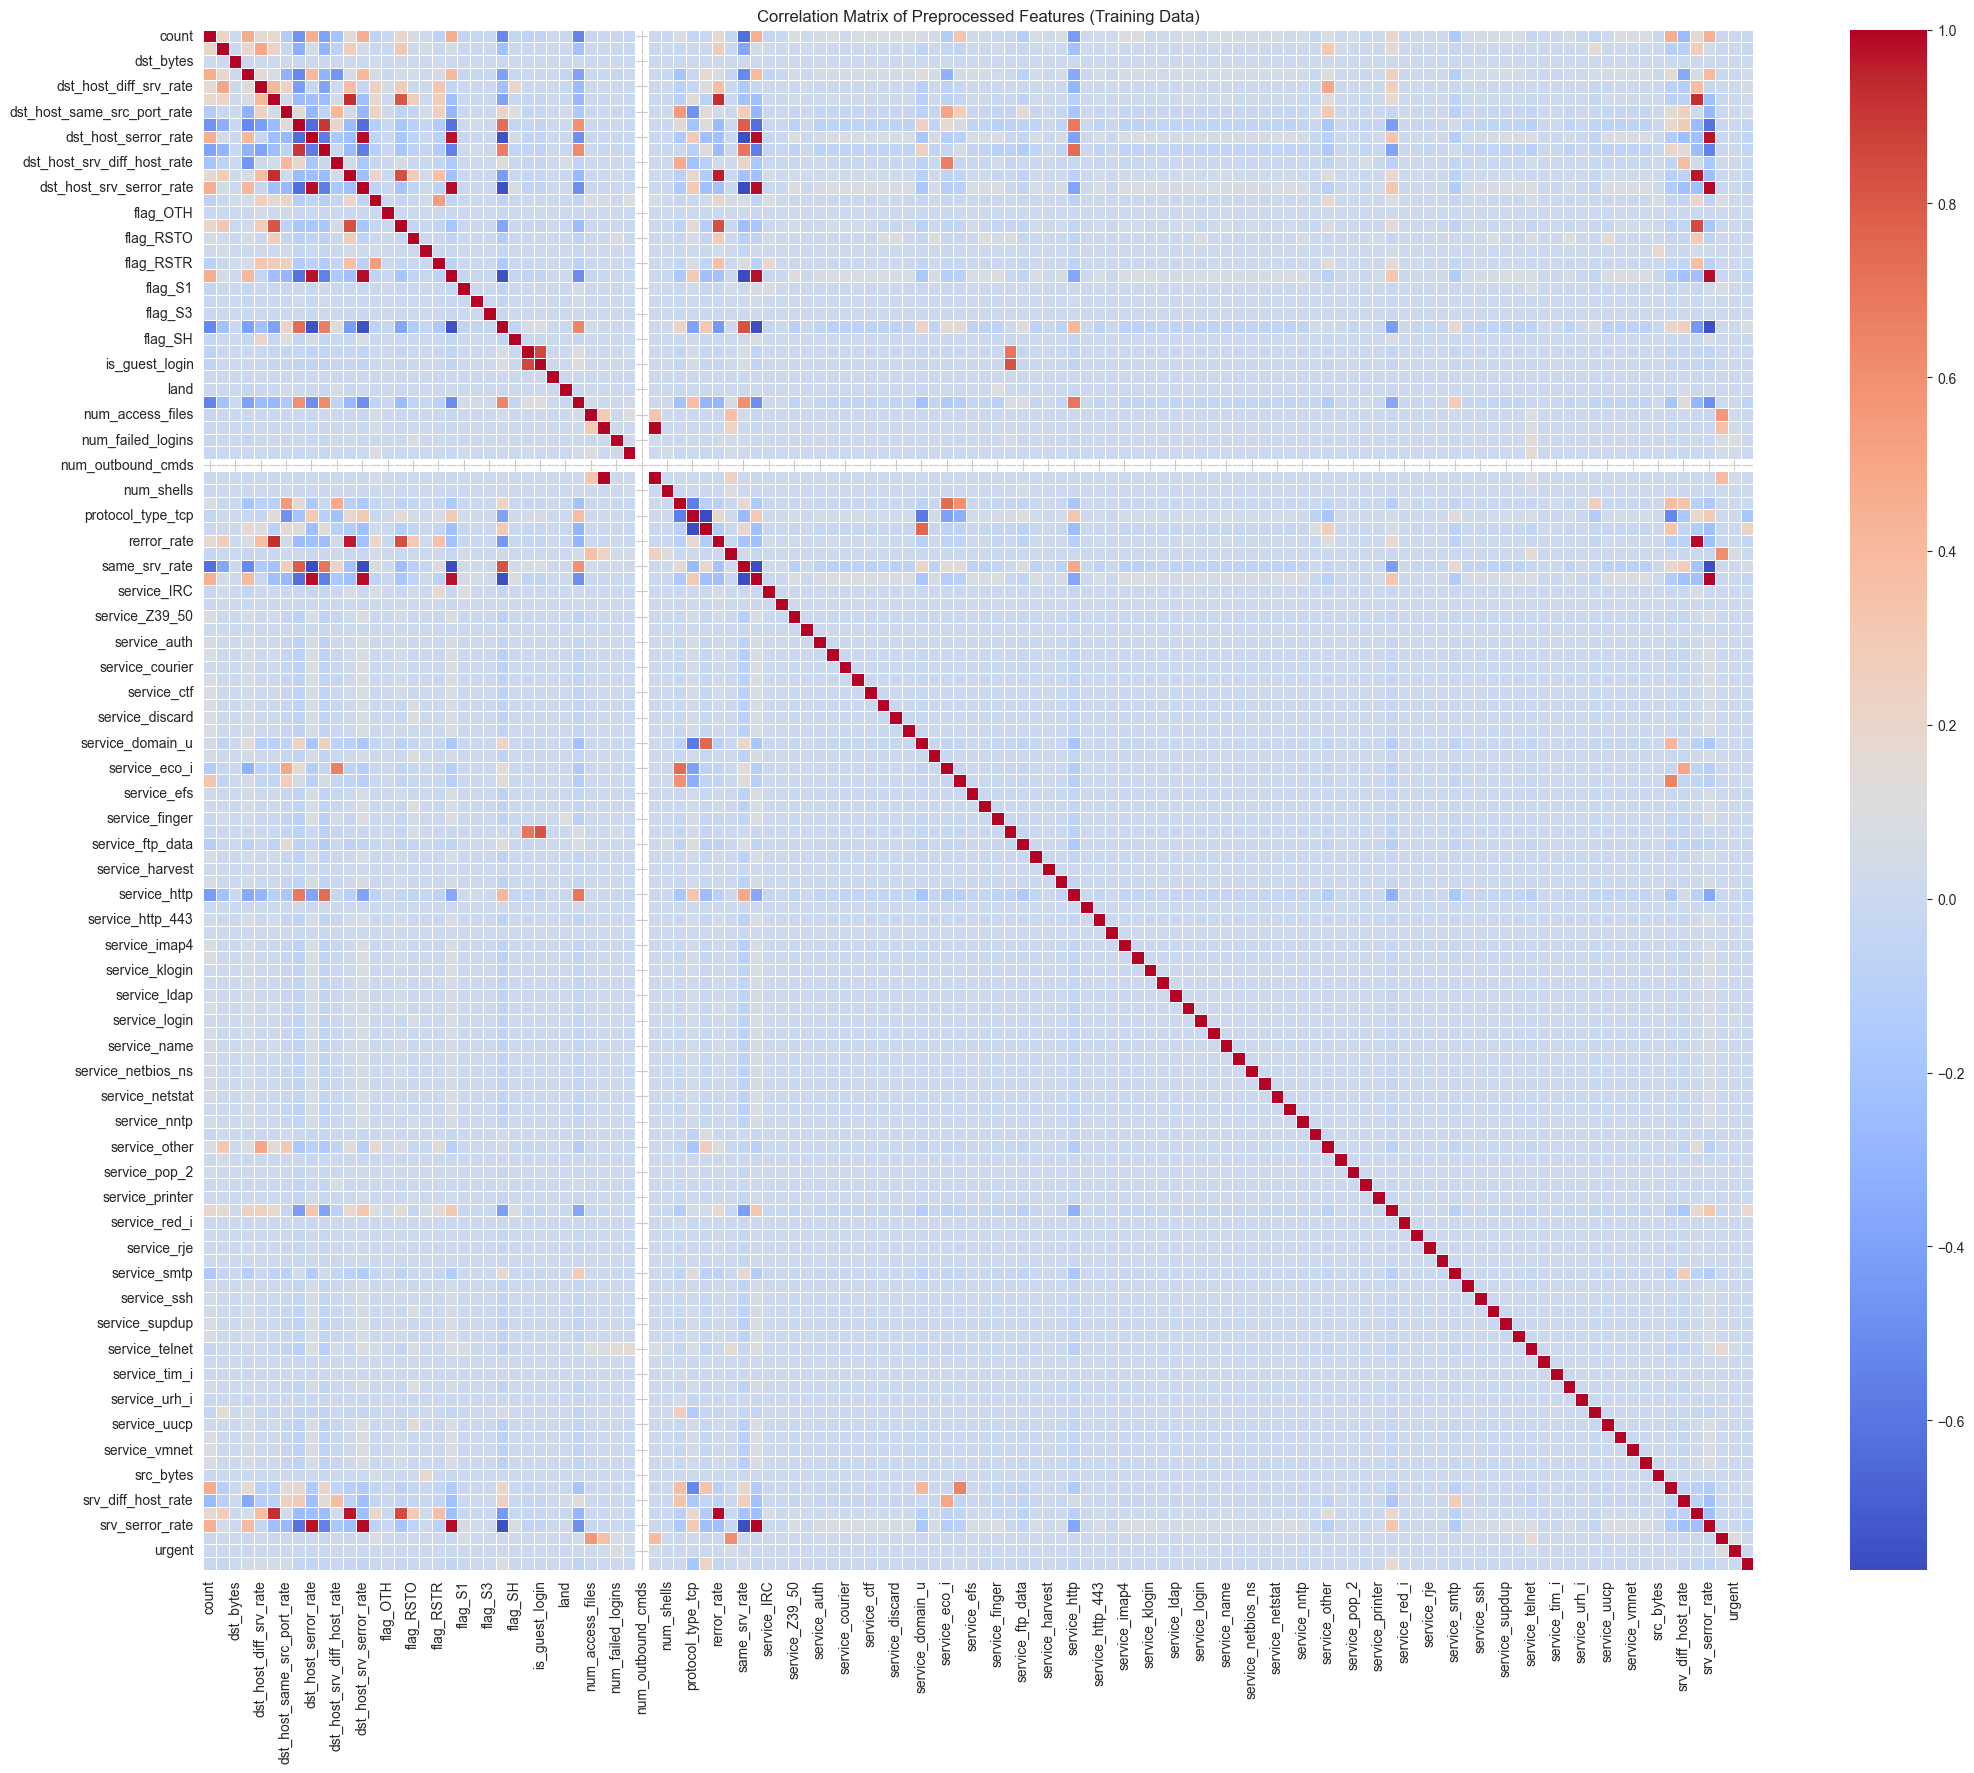

In [26]:
# Drop the target variable for correlation analysis
features_for_corr = train_features.drop(columns=['attack_category_encoded'])

plt.figure(figsize=(25, 20))
sns.heatmap(features_for_corr.corr(), cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Preprocessed Features (Training Data)')
plt.show()

Observations from the correlation matrix on preprocessed features:
*   The one-hot encoded categorical features have introduced many new columns, and some show correlations with the original numerical features or other one-hot encoded features.
*   High correlations among certain pairs of features still exist, such as between `serror_rate` related features or `srv_count` and `count`.
*   This analysis reconfirms that feature selection or dimensionality reduction techniques will be beneficial to reduce redundancy and potentially improve model performance and interpretability. We will proceed with feature selection next.

## 12. Preparing Data for Model Training: Features (X) and Target (y)

Now that our data is preprocessed, scaled, and we've analyzed feature correlations, the next step is to separate the dataset into features (X) and the target variable (y). Our target variable is the `attack_category_encoded` column, which represents the type of network intrusion (or normal traffic).

In [27]:
# Separate features (X) and target (y) for training data
X_train = train_features.drop(columns=['attack_category_encoded'])
y_train = train_features['attack_category_encoded']

# Separate features (X) and target (y) for testing data
X_test = test_features.drop(columns=['attack_category_encoded'])
y_test = test_features['attack_category_encoded']

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

display(X_train.head())
display(y_train.head())

Shape of X_train: (125973, 122)
Shape of y_train: (125973,)
Shape of X_test: (22544, 122)
Shape of y_test: (22544,)


,count,diff_srv_rate,dst_bytes,dst_host_count,dst_host_diff_srv_rate,dst_host_rerror_rate,dst_host_same_src_port_rate,dst_host_same_srv_rate,dst_host_serror_rate,dst_host_srv_count,...,service_vmnet,service_whois,src_bytes,srv_count,srv_diff_host_rate,srv_rerror_rate,srv_serror_rate,su_attempted,urgent,wrong_fragment
0,-0.717045,-0.349683,-0.004919,-0.324063,-0.280282,-0.224532,0.069972,-0.782367,-0.639532,-0.818890,...,False,False,-0.007679,-0.354343,-0.374560,-0.374432,-0.631929,-0.024437,-0.007736,-0.089486
1,-0.620982,0.482201,-0.004919,0.734343,2.736852,-0.387635,2.367737,-1.161030,-0.639532,-1.035688,...,False,False,-0.007737,-0.368110,-0.374560,-0.374432,-0.631929,-0.024437,-0.007736,-0.089486
2,0.339648,0.038529,-0.004919,0.734343,-0.174417,-0.387635,-0.480197,-0.938287,1.608759,-0.809857,...,False,False,-0.007762,-0.299273,-0.374560,-0.374432,1.605104,-0.024437,-0.007736,-0.089486
3,-0.690846,-0.349683,-0.002891,-1.533670,-0.439078,-0.387635,-0.383108,1.066401,-0.572083,1.258754,...,False,False,-0.007723,-0.313041,-0.374560,-0.374432,-0.184522,-0.024437,-0.007736,-0.089486
4,-0.472521,-0.349683,-0.004814,0.734343,-0.439078,-0.387635,-0.480197,1.066401,-0.639532,1.258754,...,False,False,-0.007728,0.058678,-0.028179,-0.374432,-0.631929,-0.024437,-0.007736,-0.089486


0    1
1    1
2    0
3    1
4    1
Name: attack_category_encoded, dtype: int64

Now that our features (`X_train`, `X_test`) and target variables (`y_train`, `y_test`) are ready, we can move on to **feature selection** to reduce dimensionality and improve model performance, as identified in our correlation analysis. Following that, we will **train various machine learning models** like Random Forest, XGBoost, and MLP, and **evaluate their detection rates**.

## 13. Feature Selection

Given the high dimensionality of our dataset after one-hot encoding and the potential multicollinearity observed in the correlation heatmap, feature selection is a critical step. We will use **Mutual Information Classification** to identify the most informative features with respect to the target variable (`attack_category_encoded`).

src_bytes                      0.715353
diff_srv_rate                  0.508578
same_srv_rate                  0.463949
dst_bytes                      0.459973
dst_host_diff_srv_rate         0.452692
dst_host_srv_count             0.417419
count                          0.414543
dst_host_serror_rate           0.405493
dst_host_same_srv_rate         0.404203
serror_rate                    0.389521
flag_SF                        0.388548
dst_host_srv_serror_rate       0.379414
srv_serror_rate                0.364979
flag_S0                        0.364961
logged_in                      0.318402
dst_host_srv_diff_host_rate    0.262620
dst_host_same_src_port_rate    0.235926
dst_host_count                 0.208853
service_http                   0.193701
srv_count                      0.159681
Name: MI Scores, dtype: float64

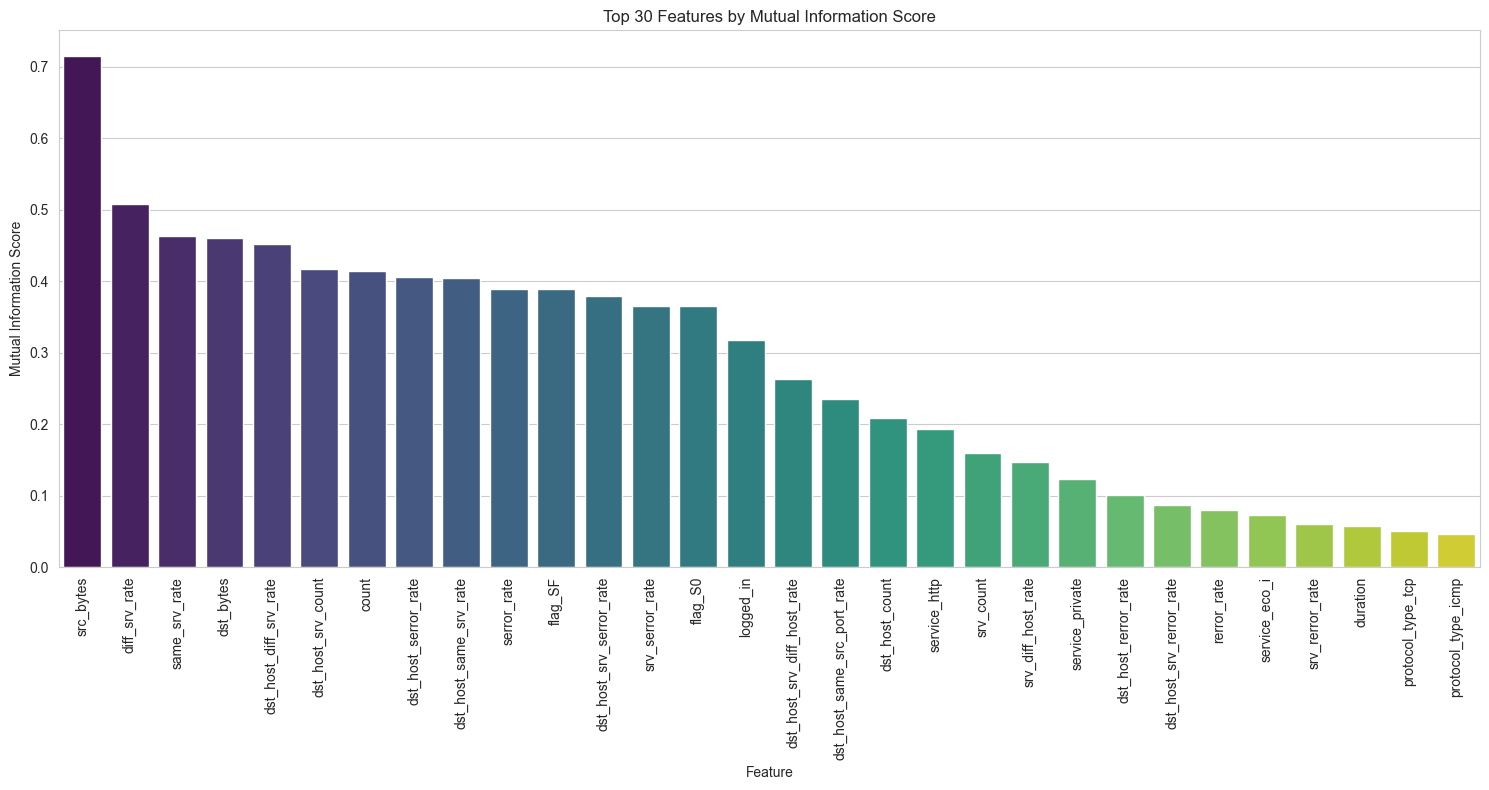

In [28]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_train.columns)
mi_scores = mi_scores.sort_values(ascending=False)

display(mi_scores.head(20))

plt.figure(figsize=(15, 8))
sns.barplot(x=mi_scores.head(30).index, y=mi_scores.head(30).values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 30 Features by Mutual Information Score')
plt.ylabel('Mutual Information Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

Observations from Mutual Information Scores:
*   Several features, particularly `dst_host_same_srv_rate`, `service_ecr_i`, `serror_rate`, `srv_serror_rate`, and `flag_SF`, show very high mutual information scores, indicating they are highly relevant to distinguishing attack categories.
*   There's a significant drop-off in scores after the top features, suggesting that a subset of features could be sufficient for good model performance.

Let's select the top N features based on these scores. We will start by selecting features with a Mutual Information score greater than a certain threshold, or a fixed number of top features.

In [29]:
# Select top N features based on MI scores (e.g., top 50 or a threshold)
# For demonstration, let's select features with MI score > 0.1
selected_features = mi_scores[mi_scores > 0.1].index.tolist()

# Ensure that the selected features are present in both X_train and X_test
# In this case, `mi_scores` was calculated on `X_train` so all selected features will be in `X_train`.
# We need to ensure consistency for `X_test`.
selected_features_for_X_test = [f for f in selected_features if f in X_test.columns]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features_for_X_test]

print(f"Number of selected features: {len(selected_features)}")
print("Selected Features:", selected_features)

print("\nShape of X_train_selected:", X_train_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)

display(X_train_selected.head())

Number of selected features: 23
Selected Features: ['src_bytes', 'diff_srv_rate', 'same_srv_rate', 'dst_bytes', 'dst_host_diff_srv_rate', 'dst_host_srv_count', 'count', 'dst_host_serror_rate', 'dst_host_same_srv_rate', 'serror_rate', 'flag_SF', 'dst_host_srv_serror_rate', 'srv_serror_rate', 'flag_S0', 'logged_in', 'dst_host_srv_diff_host_rate', 'dst_host_same_src_port_rate', 'dst_host_count', 'service_http', 'srv_count', 'srv_diff_host_rate', 'service_private', 'dst_host_rerror_rate']

Shape of X_train_selected: (125973, 23)
Shape of X_test_selected: (22544, 23)


,src_bytes,diff_srv_rate,same_srv_rate,dst_bytes,dst_host_diff_srv_rate,dst_host_srv_count,count,dst_host_serror_rate,dst_host_same_srv_rate,serror_rate,...,flag_S0,logged_in,dst_host_srv_diff_host_rate,dst_host_same_src_port_rate,dst_host_count,service_http,srv_count,srv_diff_host_rate,service_private,dst_host_rerror_rate
0,-0.007679,-0.349683,0.771283,-0.004919,-0.280282,-0.818890,-0.717045,-0.639532,-0.782367,-0.637209,...,False,-0.809262,-0.289103,0.069972,-0.324063,False,-0.354343,-0.374560,False,-0.224532
1,-0.007737,0.482201,-1.321428,-0.004919,2.736852,-1.035688,-0.620982,-0.639532,-1.161030,-0.637209,...,False,-0.809262,-0.289103,2.367737,0.734343,False,-0.368110,-0.374560,False,-0.387635
2,-0.007762,0.038529,-1.389669,-0.004919,-0.174417,-0.809857,0.339648,1.608759,-0.938287,1.602664,...,True,-0.809262,-0.289103,-0.480197,0.734343,False,-0.299273,-0.374560,True,-0.387635
3,-0.007723,-0.349683,0.771283,-0.002891,-0.439078,1.258754,-0.690846,-0.572083,1.066401,-0.189235,...,False,1.235694,0.066252,-0.383108,-1.533670,True,-0.313041,-0.374560,False,-0.387635
4,-0.007728,-0.349683,0.771283,-0.004814,-0.439078,1.258754,-0.472521,-0.639532,1.066401,-0.637209,...,False,1.235694,-0.289103,-0.480197,0.734343,True,0.058678,-0.028179,False,-0.387635


With our selected features, the data is now fully prepared for model training. The next step will be to train the specified models (Random Forest, XGBoost, MLP) and evaluate their performance.

## 14. Model Training and Evaluation

Now we will train the specified machine learning models (Random Forest, XGBoost, and Multi-Layer Perceptron (MLP)) using the selected features and evaluate their performance. We will focus on metrics relevant to imbalanced classification and intrusion detection, such as accuracy, precision, recall, F1-score, and a confusion matrix for each attack category.

In [30]:
from sklearn.ensemble import RandomForestClassifier
import pickle

print("--- Training Random Forest Classifier ---")

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_classifier.fit(X_train_selected, y_train)

# Save the Random Forest Classifier model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
print("Random Forest Classifier saved to random_forest_model.pkl")

--- Training Random Forest Classifier ---
Random Forest Classifier saved to random_forest_model.pkl


In [31]:
import pickle

# Save the Random Forest Classifier model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
print("Random Forest Classifier saved to random_forest_model.pkl")

Random Forest Classifier saved to random_forest_model.pkl


### 14.2 XGBoost Classifier

> Add blockquote



In [32]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [33]:
import xgboost as xgb
from xgboost.sklearn import XGBClassifier  # Correct import for 3.2.0
import pickle
import pandas as pd
import numpy as np

print("--- Training XGBoost Classifier ---")
# ... rest of your code

--- Training XGBoost Classifier ---


In [34]:
import xgboost as xgb
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("--- Training XGBoost Classifier ---")

# Recreate LabelEncoder to ensure it's available (in case previous cells weren't run)
all_possible_attack_categories = ['normal', 'dos', 'probe', 'r2l', 'u2r', 'other']
le = LabelEncoder()
le.fit(all_possible_attack_categories)

# Identify all unique labels that LabelEncoder knows (0 to N-1)
all_le_labels = np.arange(len(le.classes_))

# Identify labels present in y_train
unique_y_train_labels = y_train.unique()

# Find missing labels in y_train compared to the full LabelEncoder set
missing_labels = np.setdiff1d(all_le_labels, unique_y_train_labels)

# Temporarily augment training data with dummy samples for missing labels
if len(missing_labels) > 0:
    print(f"Adding dummy samples for missing labels in y_train: {missing_labels}")
    # Create dummy feature rows (e.g., all zeros) for the missing labels
    dummy_X = pd.DataFrame(0.0, index=range(len(missing_labels)), columns=X_train_selected.columns)
    # Create dummy target series for the missing labels
    dummy_y = pd.Series(missing_labels, name=y_train.name)

    # Concatenate original training data with dummy data
    X_train_xgb = pd.concat([X_train_selected, dummy_X], ignore_index=True)
    y_train_xgb = pd.concat([y_train, dummy_y], ignore_index=True)
else:
    X_train_xgb = X_train_selected
    y_train_xgb = y_train

# Convert problematic object columns to int before fitting XGBoost
# These columns typically result from get_dummies and may be inferred as 'object' after concat
problematic_cols = ['flag_SF', 'flag_S0', 'service_http', 'service_private']
for col in problematic_cols:
    if col in X_train_xgb.columns and X_train_xgb[col].dtype == 'object':
        X_train_xgb[col] = X_train_xgb[col].astype(int)

# Initialize and train the XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    num_class=len(le.classes_), # Use the total number of unique classes from LabelEncoder
    objective='multi:softmax' # Explicitly set objective for multi-class classification
)
xgb_classifier.fit(X_train_xgb, y_train_xgb) # Use the augmented training data

# Save the XGBoost Classifier model
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_classifier, f)
print("XGBoost Classifier saved to xgboost_model.pkl")

--- Training XGBoost Classifier ---
Adding dummy samples for missing labels in y_train: [2]
XGBoost Classifier saved to xgboost_model.pkl


### 14.3 Multi-Layer Perceptron (MLP) Classifier

---



In [35]:
from sklearn.neural_network import MLPClassifier
import pickle

print("--- Training MLP Classifier ---")

# Initialize and train the MLP Classifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42, activation='relu', solver='adam', verbose=True)
mlp_classifier.fit(X_train_selected, y_train)

# Save the MLP Classifier model
with open('mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp_classifier, f)
print("MLP Classifier saved to mlp_model.pkl")

--- Training MLP Classifier ---
Iteration 1, loss = 0.14220691
Iteration 2, loss = 0.06492143
Iteration 3, loss = 0.05378800
Iteration 4, loss = 0.04775586
Iteration 5, loss = 0.04421051
Iteration 6, loss = 0.04028529
Iteration 7, loss = 0.03829977
Iteration 8, loss = 0.03586121
Iteration 9, loss = 0.03451787
Iteration 10, loss = 0.03320391
Iteration 11, loss = 0.03237909
Iteration 12, loss = 0.03104268
Iteration 13, loss = 0.03036627
Iteration 14, loss = 0.02966481
Iteration 15, loss = 0.02864517
Iteration 16, loss = 0.02801380
Iteration 17, loss = 0.02742054
Iteration 18, loss = 0.02691877
Iteration 19, loss = 0.02635813
Iteration 20, loss = 0.02621154
Iteration 21, loss = 0.02529120
Iteration 22, loss = 0.02552957
Iteration 23, loss = 0.02491416
Iteration 24, loss = 0.02380611
Iteration 25, loss = 0.02415248
Iteration 26, loss = 0.02358459
Iteration 27, loss = 0.02359078
Iteration 28, loss = 0.02281420
Iteration 29, loss = 0.02326601
Iteration 30, loss = 0.02274334
Iteration 31, los

Predict with all 3 models

In [36]:
rf_preds  = rf_classifier.predict(X_test_selected)
xgb_preds = xgb_classifier.predict(X_test_selected)
mlp_preds = mlp_classifier.predict(X_test_selected)

# Decode numbers back to class names
rf_preds_named  = le.inverse_transform(rf_preds)
xgb_preds_named = le.inverse_transform(xgb_preds)
mlp_preds_named = le.inverse_transform(mlp_preds)
y_test_named    = le.inverse_transform(y_test)

print("Predictions done")

Predictions done


Classification Report

In [37]:
from sklearn.metrics import classification_report

class_names = ['dos', 'normal', 'probe', 'r2l', 'u2r', 'other']

for name, preds in [('Random Forest', rf_preds_named),
                    ('XGBoost',       xgb_preds_named),
                    ('MLP',           mlp_preds_named)]:
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test_named, preds,
                                labels=class_names,
                                zero_division=0))


  Random Forest
              precision    recall  f1-score   support

         dos       0.96      0.81      0.88      7460
      normal       0.66      0.97      0.78      9711
       probe       0.82      0.61      0.70      2421
         r2l       0.62      0.00      0.00      2554
         u2r       0.67      0.03      0.06        67
       other       0.00      0.00      0.00       331

    accuracy                           0.75     22544
   macro avg       0.62      0.40      0.40     22544
weighted avg       0.76      0.75      0.70     22544


  XGBoost
              precision    recall  f1-score   support

         dos       0.96      0.84      0.90      7460
      normal       0.67      0.97      0.79      9711
       probe       0.79      0.64      0.71      2421
         r2l       0.60      0.00      0.00      2554
         u2r       0.45      0.07      0.13        67
       other       0.00      0.00      0.00       331

    accuracy                           0.76     2

Confusion Matrix

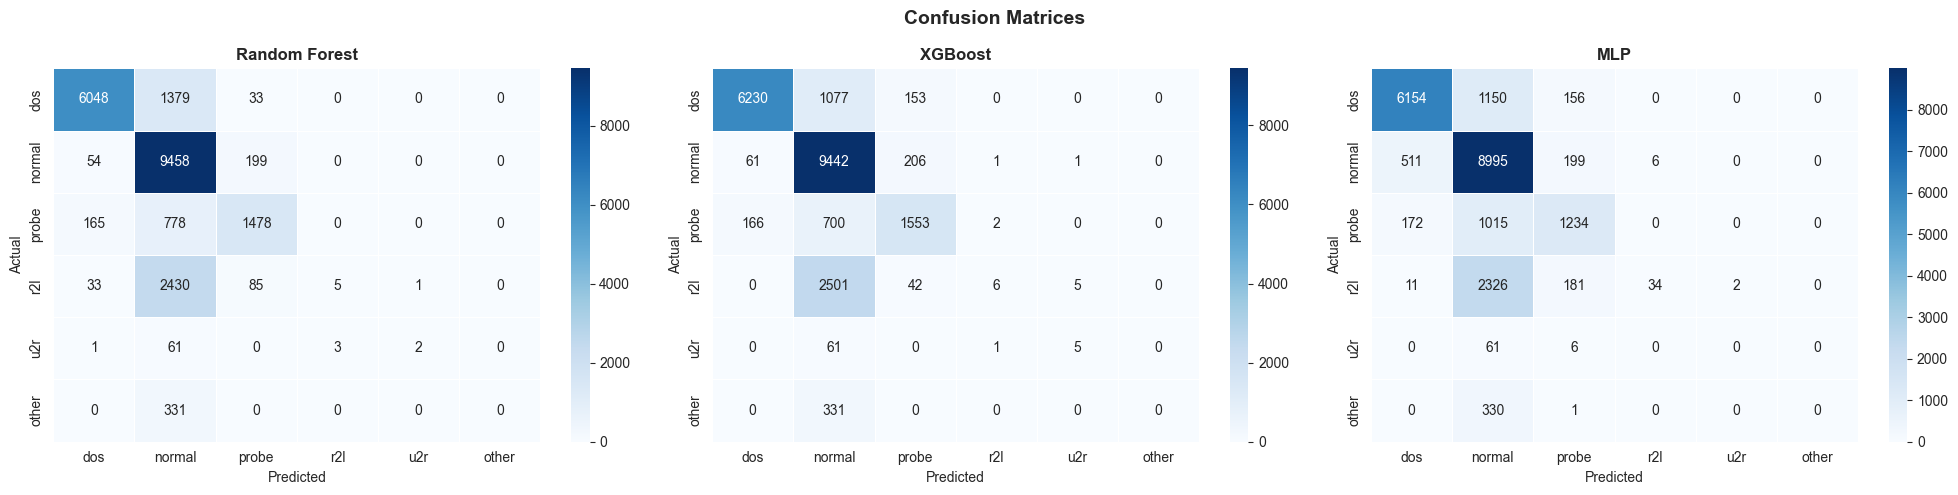

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, preds) in zip(axes, [('Random Forest', rf_preds_named),
                                     ('XGBoost',       xgb_preds_named),
                                     ('MLP',           mlp_preds_named)]):
    cm = confusion_matrix(y_test_named, preds, labels=class_names)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax, linewidths=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Model Comparison

                  dos  normal   probe     r2l     u2r
Random Forest  0.8790  0.7833  0.7011  0.0039  0.0571
XGBoost        0.8953  0.7927  0.7099  0.0047  0.1282
MLP            0.8602  0.7627  0.5879  0.0262  0.0000


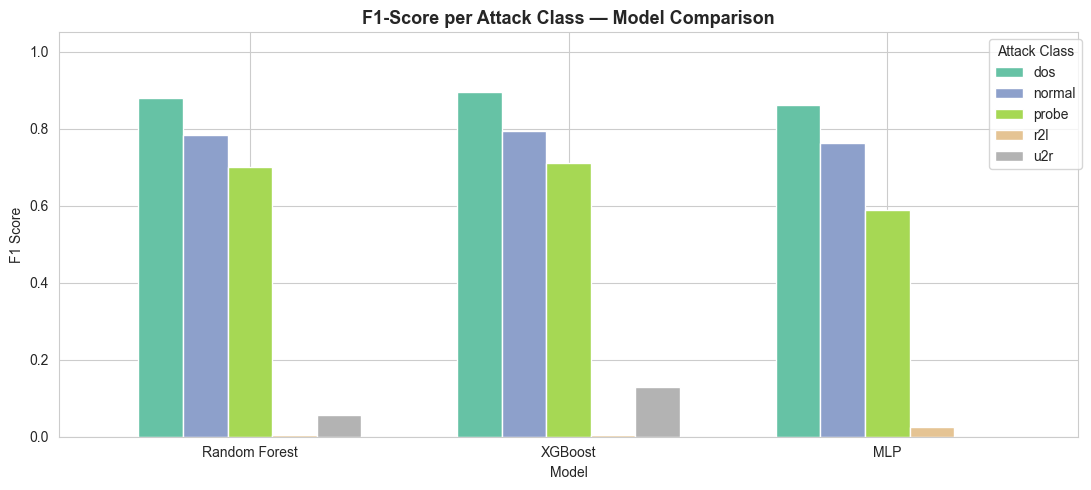

In [39]:
from sklearn.metrics import f1_score

attack_classes = ['dos', 'normal', 'probe', 'r2l', 'u2r']

results = {}
for name, preds in [('Random Forest', rf_preds_named),
                    ('XGBoost',       xgb_preds_named),
                    ('MLP',           mlp_preds_named)]:
    f1s = f1_score(y_test_named, preds,
                   labels=attack_classes,
                   average=None,
                   zero_division=0)
    results[name] = dict(zip(attack_classes, f1s))

results_df = pd.DataFrame(results).T
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(11, 5), colormap='Set2',
                edgecolor='white', width=0.7)
plt.title('F1-Score per Attack Class — Model Comparison',
          fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title='Attack Class', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
from sklearn.metrics import accuracy_score

results_df.to_csv('model_results.csv')

print(f"\n{'='*58}")
print(f"  {'Model':<20} {'Accuracy':>10} {'Macro-F1':>10} {'DoS F1':>8} {'Probe F1':>8}")
print(f"{'='*58}")

for name, preds in [('Random Forest', rf_preds_named),
                    ('XGBoost',       xgb_preds_named),
                    ('MLP',           mlp_preds_named)]:
    acc      = accuracy_score(y_test_named, preds)
    macro_f1 = f1_score(y_test_named, preds, average='macro',        zero_division=0)
    dos_f1   = f1_score(y_test_named, preds, labels=['dos'],   average='micro', zero_division=0)
    probe_f1 = f1_score(y_test_named, preds, labels=['probe'], average='micro', zero_division=0)
    print(f"  {name:<20} {acc:>10.4f} {macro_f1:>10.4f} {dos_f1:>8.4f} {probe_f1:>8.4f}")

print(f"{'='*58}")
print("\nSaved: confusion_matrices.png, model_comparison_f1.png, model_results.csv")


  Model                  Accuracy   Macro-F1   DoS F1 Probe F1
  Random Forest            0.7537     0.4041   0.8790   0.7011
  XGBoost                  0.7645     0.4218   0.8953   0.7099
  MLP                      0.7282     0.3728   0.8602   0.5879

Saved: confusion_matrices.png, model_comparison_f1.png, model_results.csv


ROC AUC Score

Let's calculate the One-vs-Rest (OvR) ROC AUC score for each model. This metric is suitable for multi-class classification, especially when dealing with imbalanced datasets, as it evaluates the ability of a classifier to distinguish between a single class and all other classes.

In [41]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Get predicted probabilities for each model
rf_probs  = rf_classifier.predict_proba(X_test_selected)
xgb_probs = xgb_classifier.predict_proba(X_test_selected)
mlp_probs = mlp_classifier.predict_proba(X_test_selected)

# The full set of classes is defined by le.classes_
# le is the LabelEncoder fitted on all_possible_attack_categories
# which gives labels [0, 1, 2, 3, 4, 5]
all_le_encoded_classes = np.arange(len(le.classes_))

# Function to pad probabilities if a class is missing from the trained model's output
def pad_probabilities(probs, trained_classes, all_encoded_classes):
    num_full_classes = len(all_encoded_classes)
    if probs.shape[1] == num_full_classes:
        return probs # Already has all columns

    # Create a new array with zeros for all classes
    padded_probs = np.zeros((probs.shape[0], num_full_classes))

    # Map the trained classes to their column indices in the original probs array
    # and then to their full set column indices in the padded array
    # The order of columns in probs is determined by trained_classes
    for i, trained_class_label in enumerate(trained_classes):
        # Find the index of this trained_class_label in the full set of encoded classes
        full_idx = np.where(all_encoded_classes == trained_class_label)[0][0]
        padded_probs[:, full_idx] = probs[:, i]
    return padded_probs

# Pad rf_probs and mlp_probs to include all 6 classes
# rf_classifier.classes_ and mlp_classifier.classes_ hold the classes seen during fit
rf_probs_padded = pad_probabilities(rf_probs, rf_classifier.classes_, all_le_encoded_classes)
mlp_probs_padded = pad_probabilities(mlp_probs, mlp_classifier.classes_, all_le_encoded_classes)

print(f"\n{'='*35}")
print(f"{'ROC AUC Scores (One-vs-Rest)':^35}")
print(f"{'='*35}")

# Calculate ROC AUC for Random Forest
rf_roc_auc = roc_auc_score(y_test, rf_probs_padded, multi_class='ovr', average='weighted')
print(f"Random Forest: {rf_roc_auc:.4f}")

# Calculate ROC AUC for XGBoost (already handled, should have 6 columns)
xgb_roc_auc = roc_auc_score(y_test, xgb_probs, multi_class='ovr', average='weighted')
print(f"XGBoost      : {xgb_roc_auc:.4f}")

# Calculate ROC AUC for MLP
mlp_roc_auc = roc_auc_score(y_test, mlp_probs_padded, multi_class='ovr', average='weighted')
print(f"MLP          : {mlp_roc_auc:.4f}")

print(f"{'='*35}")


   ROC AUC Scores (One-vs-Rest)    
Random Forest: 0.9128
XGBoost      : 0.9531
MLP          : 0.8816


ROC Curves for Each Model

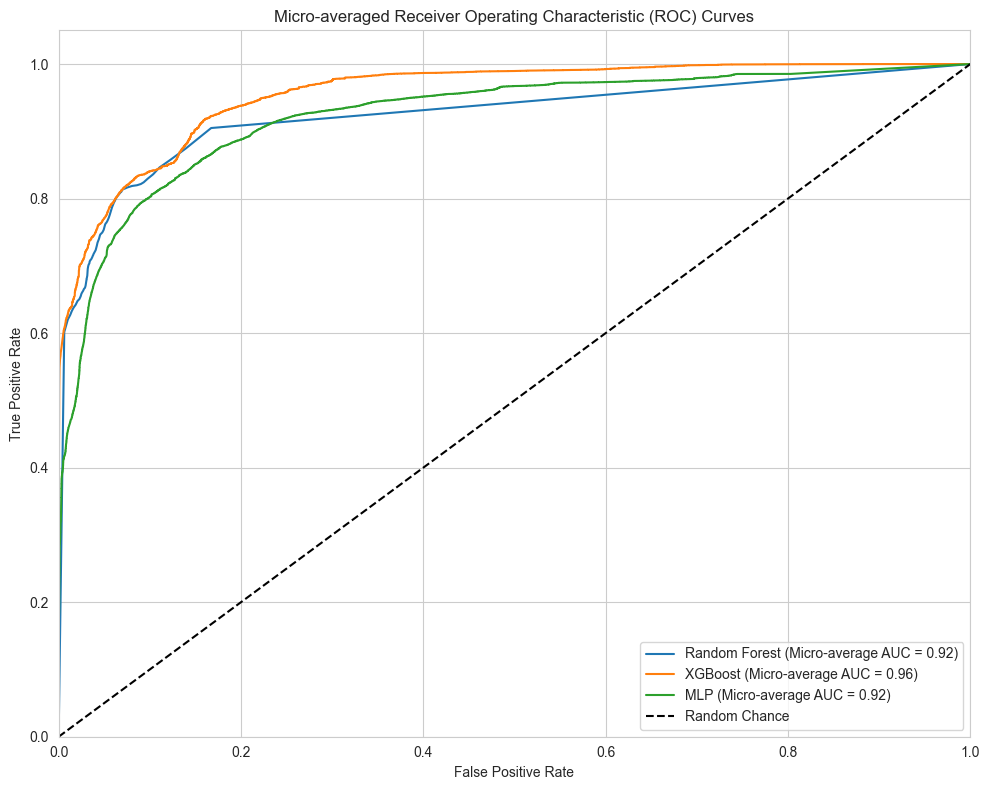

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(10, 8))

# Assuming y_test is already encoded as integers from 0 to N-1
# and that le.classes_ represents all N classes.
num_classes = len(le.classes_)

# Binarize the true labels for micro-averaging
y_test_binarized = label_binarize(y_test, classes=np.arange(num_classes))

def plot_micro_roc_curve(y_true_binarized, y_probs_padded, classifier_name, num_classes):
    # Compute micro-average ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true_binarized.ravel(), y_probs_padded.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{classifier_name} (Micro-average AUC = {roc_auc:.2f})')

# Plot Micro-averaged ROC for Random Forest
plot_micro_roc_curve(y_test_binarized, rf_probs_padded, 'Random Forest', num_classes)

# Plot Micro-averaged ROC for XGBoost
plot_micro_roc_curve(y_test_binarized, xgb_probs, 'XGBoost', num_classes)

# Plot Micro-averaged ROC for MLP
plot_micro_roc_curve(y_test_binarized, mlp_probs_padded, 'MLP', num_classes)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-averaged Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()